# Modeling - Homophily

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
from baseline_utils import fit_degroot_adjacency_scalar, degroot_rollout_prediction, evaluate_validation_model
from opinion_fitting import fit_homophily, rollout_with_homophily, fit_homophily_stubborness, rollout_with_homophily_stubborness
from plot_utils import (
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
)

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/debate_topics
Runs found: 10
  run_20260424-005252
  run_20260424-012328
  run_20260424-015401
  run_20260424-022443
  run_20260424-025520
  run_20260424-032603
  run_20260424-035640
  run_20260424-042719
  run_20260424-045748
  run_20260424-052818


## Data Construction

- Each run is mapped to a shared global agent index.
- Trajectories are built from the run data with the same preprocessing used in the baseline notebook.
- Neighbor sets are preserved per run for the homophily kernel.

In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f'{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}')

Global agent count: 30
Global init priors available: 30
run_20260424-005252: trajectory shape=(7, 30), horizon=6
run_20260424-012328: trajectory shape=(6, 30), horizon=5
run_20260424-015401: trajectory shape=(9, 30), horizon=8
run_20260424-022443: trajectory shape=(8, 30), horizon=7
run_20260424-025520: trajectory shape=(7, 30), horizon=6
run_20260424-032603: trajectory shape=(10, 30), horizon=9
run_20260424-035640: trajectory shape=(8, 30), horizon=7
run_20260424-042719: trajectory shape=(10, 30), horizon=9
run_20260424-045748: trajectory shape=(7, 30), horizon=6
run_20260424-052818: trajectory shape=(8, 30), horizon=7


In [3]:
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")

RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260424-005252: post_mean=0.376, post_min=0.200, post_max=0.467, slices=7
run_20260424-012328: post_mean=0.389, post_min=0.267, post_max=0.467, slices=6
run_20260424-015401: post_mean=0.352, post_min=0.033, post_max=0.467, slices=9
run_20260424-022443: post_mean=0.346, post_min=0.000, post_max=0.600, slices=8
run_20260424-025520: post_mean=0.371, post_min=0.300, post_max=0.467, slices=7
run_20260424-032603: post_mean=0.330, post_min=0.167, post_max=0.467, slices=10
run_20260424-035640: post_mean=0.346, post_min=0.167, post_max=0.533, slices=8
run_20260424-042719: post_mean=0.353, post_min=0.233, post_max=0.500, slices=10
run_20260424-045748: post_mean=0.324, post_min=0.133, post_max=0.533, slices=7
run_20260424-052818: post_mean=0.383, post_min=0.267, post_max=0.500, slices=8

Global RUN_TRAJ post-rate summary:
mean=0.355, median=0.367, min=0.000, max=0.600, total_slices=80


## Homophily

In [4]:
HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']

print('Homophily fit')
print('gamma:', HOMOPHILY_GAMMA)
print('Global pooled MSE loss:', HOMOPHILY['mse_pool'])

Homophily fit
gamma: 20.739996272483584
Global pooled MSE loss: 0.006160287493759303


In [5]:
BEST_HOMO_STUB = fit_homophily_stubborness(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    gamma0=HOMOPHILY_GAMMA,
    lambda1=0.0,
    lambda2=0.0,
    bias0=0.0,
)

homo_stub_rows = [{
    "lambda1": BEST_HOMO_STUB["lambda1"],
    "lambda2": BEST_HOMO_STUB["lambda2"],
    "gamma": BEST_HOMO_STUB["gamma"],
    "bias": BEST_HOMO_STUB["bias"],
    "mse_pool": BEST_HOMO_STUB["mse_pool"],
    "success": BEST_HOMO_STUB["success"],
    "nit": BEST_HOMO_STUB["nit"],
    "status": BEST_HOMO_STUB["status"],
}]

HOMO_STUB_LAMBDA_TABLE = pd.DataFrame(homo_stub_rows).sort_values("mse_pool").reset_index(drop=True)

print("Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)")
print("lambda1:", BEST_HOMO_STUB["lambda1"])
print("lambda2:", BEST_HOMO_STUB["lambda2"])
print("gamma:", BEST_HOMO_STUB["gamma"])
print("bias:", BEST_HOMO_STUB["bias"])
print("mse_pool:", BEST_HOMO_STUB["mse_pool"])
print("gamma grid tested:", len(BEST_HOMO_STUB.get("gamma_grid", [])))

HOMO_STUB_A = BEST_HOMO_STUB["Abar"]
HOMO_STUB_GAMMA = BEST_HOMO_STUB["gamma"]
HOMO_STUB_BIAS = BEST_HOMO_STUB["bias"]
HOMO_STUB_L1 = BEST_HOMO_STUB["lambda1"]
HOMO_STUB_L2 = BEST_HOMO_STUB["lambda2"]

HOMO_STUB_LAMBDA_TABLE.head(10)

Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)
lambda1: 0.047561385335993286
lambda2: 0.1864055679110418
gamma: 70.60076102026925
bias: 0.0893373639719268
mse_pool: 0.00565409654988632
gamma grid tested: 111


,lambda1,lambda2,gamma,bias,mse_pool,success,nit,status
0,0.047561,0.186406,70.600761,0.089337,0.005654,True,50,optimal


DeGroot adjacency gamma: 0.32690470194720533
Training metric horizon (shared): 6
Degroot


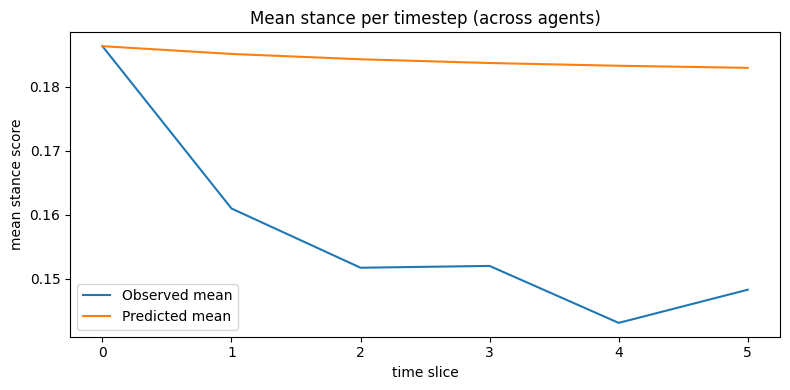

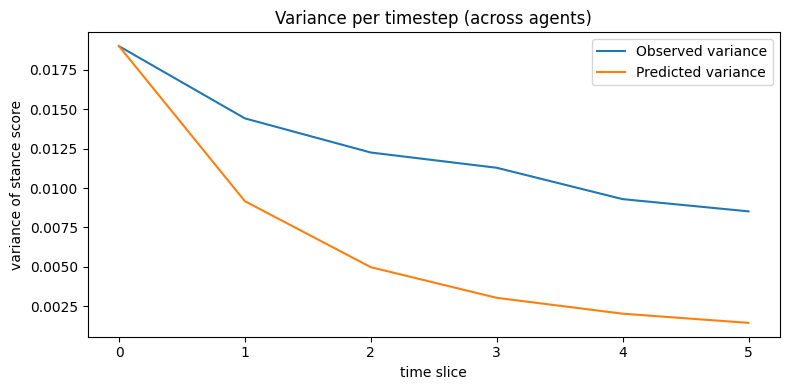

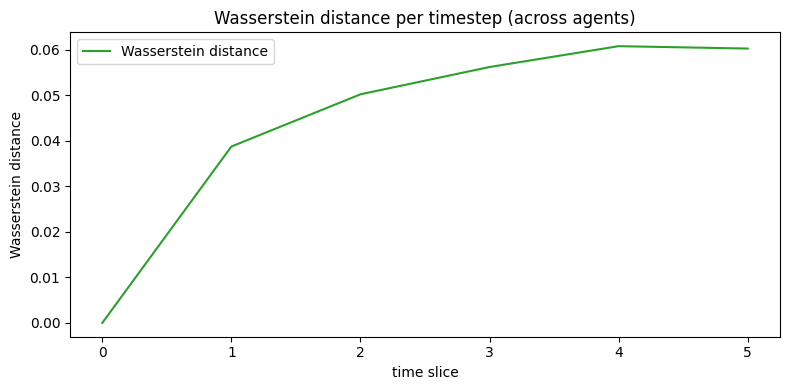

Homophliy


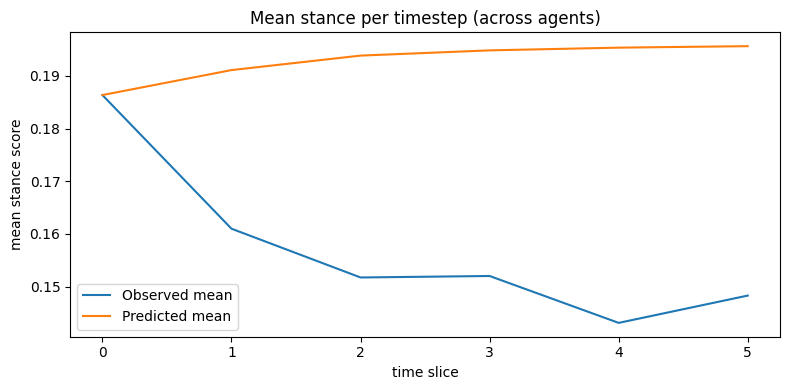

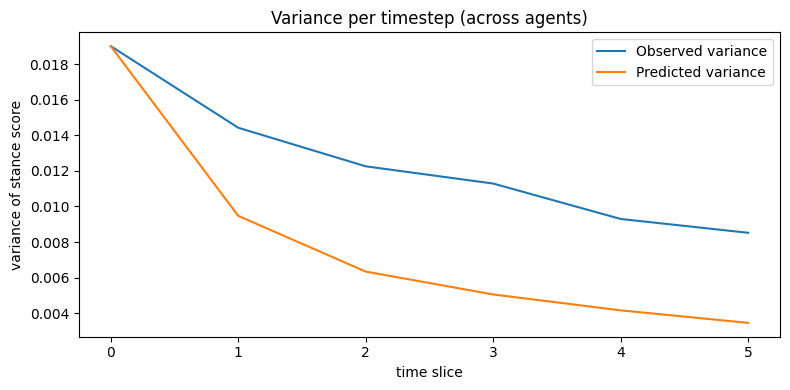

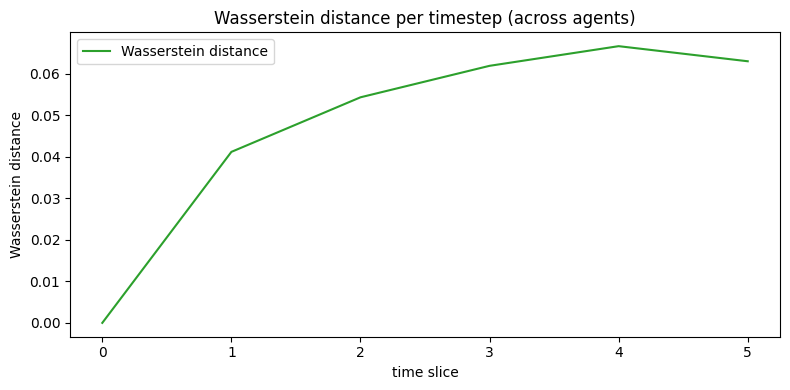

Homophliy Stuborness


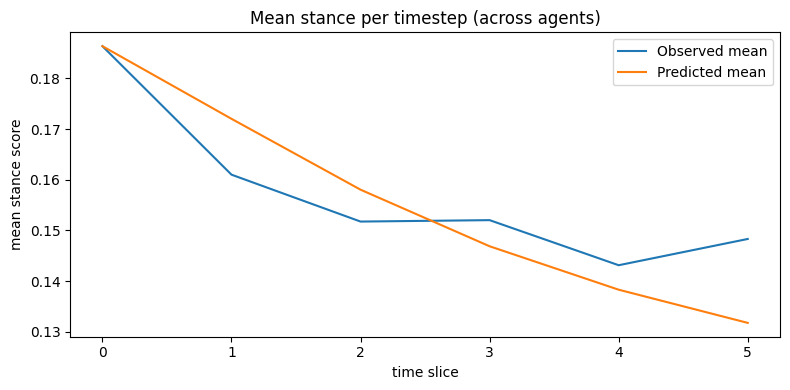

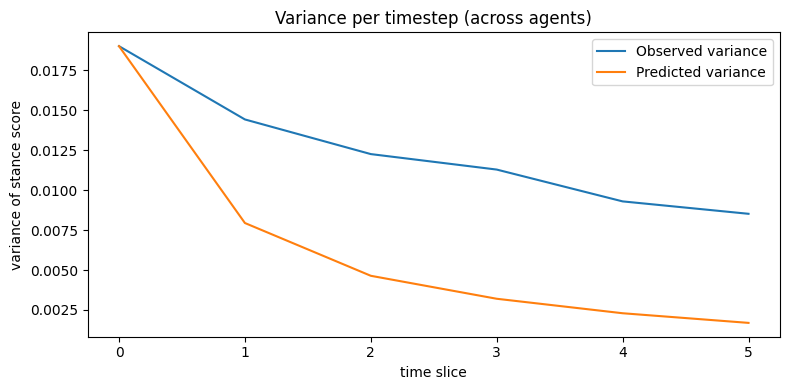

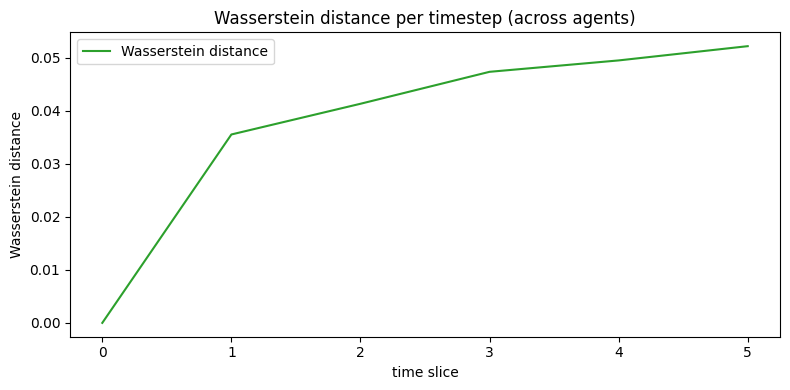

                      model  pooled_mse  transition_mse_mean  \
0  degroot_adjacency_scalar    0.005162             0.010393   
1                 homophily    0.006160             0.013004   
2     homophily_stubborness    0.005654             0.009360   

   mean_curve_abs_error  var_curve_abs_error  wasserstein_curve_mean  
0              0.031674             0.005862                0.044350  
1              0.037965             0.004552                0.047854  
2              0.019151             0.006003                0.037651  


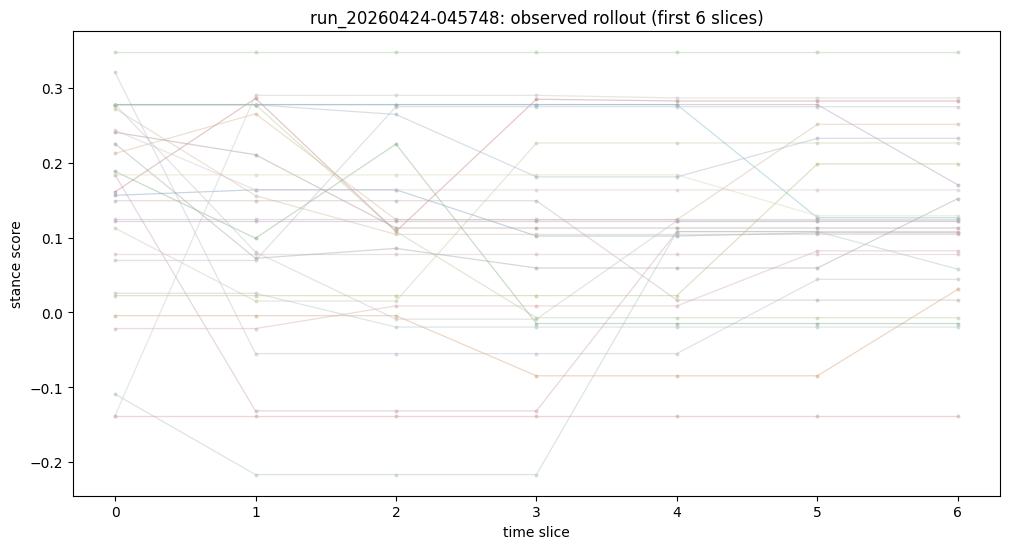

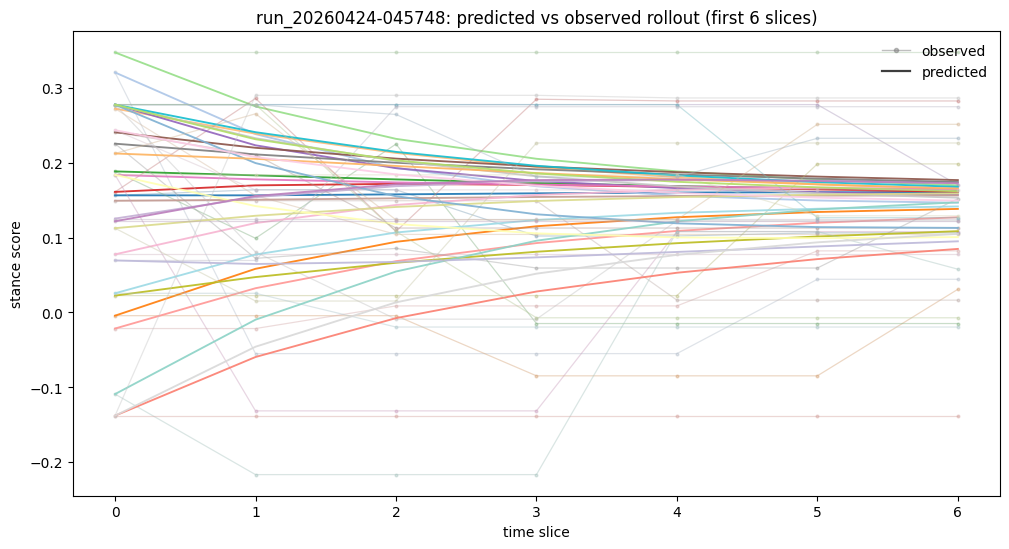

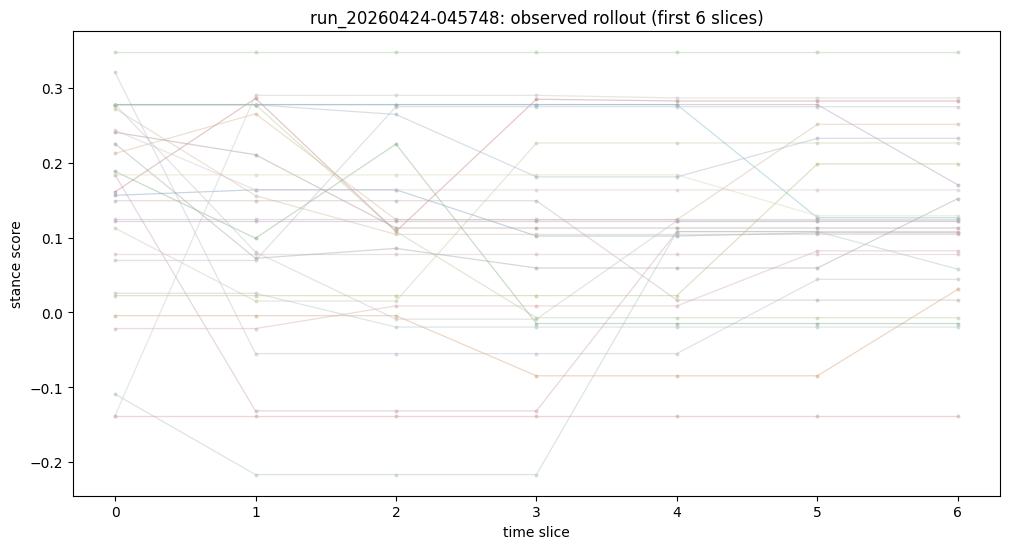

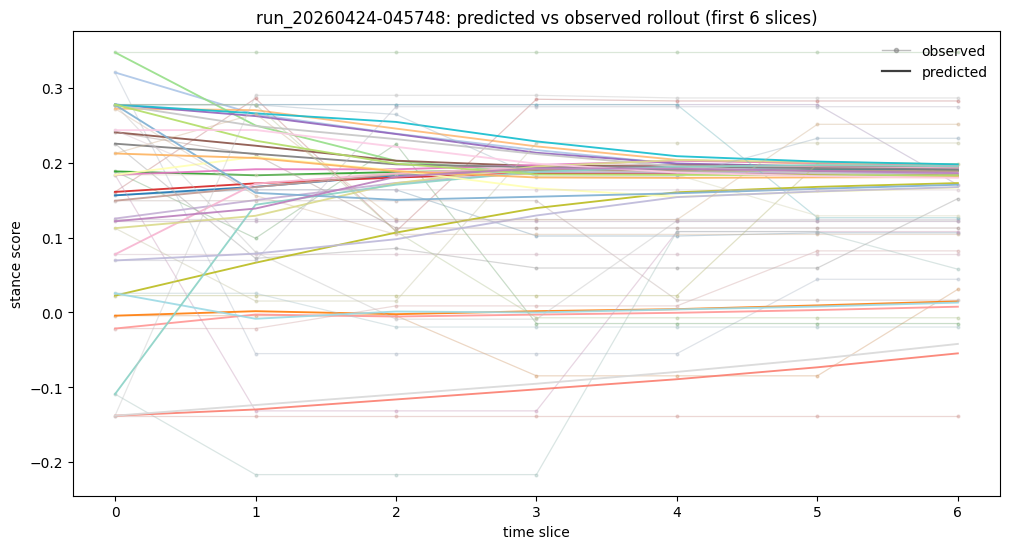

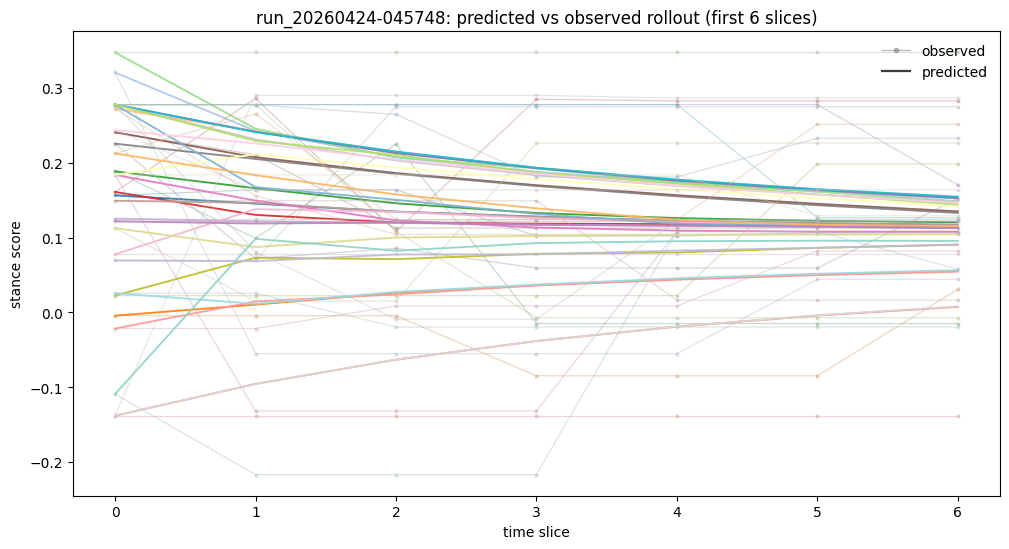

In [7]:
degroot_adj = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = degroot_adj['W']
DEGROOT_GAMMA = degroot_adj['gamma']
DEGROOT_POOL_MSE = degroot_adj['mse_pool']

PREDICTED_TRAJ_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in RUN_TRAJ.keys()
}

PREDICTED_TRAJ_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    )
    for rn in RUN_TRAJ.keys()
}

TRAIN_DEGROOT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_HOMO = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)

TRAIN_HOMO_STUB = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    ),
)

TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_HOMO['mean_true_stack'].shape[1],
    TRAIN_HOMO_STUB['mean_true_stack'].shape[1],
)
print('DeGroot adjacency gamma:', DEGROOT_GAMMA)
print('Training metric horizon (shared):', TRAIN_CURVE_HORIZON)

print("Degroot")

plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print("Homophliy")

plot_mean_per_timestep(
    TRAIN_HOMO['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
print ("Homophliy Stuborness")

plot_mean_per_timestep(
    TRAIN_HOMO_STUB["mean_true_stack"].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB["mean_pred_stack"].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO_STUB["var_true_stack"].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB["var_pred_stack"].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_STUB["wasserstein_stack"].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

train_summary = pd.DataFrame([
    {
        'model': 'degroot_adjacency_scalar',
        'pooled_mse': DEGROOT_POOL_MSE,
        'transition_mse_mean': TRAIN_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'pooled_mse': HOMOPHILY['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubborness',
        'pooled_mse': BEST_HOMO_STUB['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_STUB['wasserstein_curve_mean'],
    }
])
print(train_summary)

run_names = sorted(RUN_TRAJ.keys())
run_id = run_names[8]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], degroot_rollout_prediction(GLOBAL_W, np.asarray(RUN_TRAJ[run_id], dtype=float)[0], PARAMS['rollout_horizon_cap']), GLOBAL_AGENT_IDS, 10)
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_HOMO[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_HOMO_STUB[run_id], GLOBAL_AGENT_IDS, 10)

## Validation

In [ ]:
TEST_DATA_ROOT = ROOT / 'graphs'
TEST_RUN_DIRS = sorted([p for p in TEST_DATA_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {rn: tm[0] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {rn: build_neighbors_index(data, GLOBAL_AGENT_IDS) for rn, data in TEST_RUN_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_RUN_TRAJ.keys())
print('Validation runs found:', len(TEST_RUN_NAMES))

Validation runs found: 10


Validation metric horizon (shared): 6


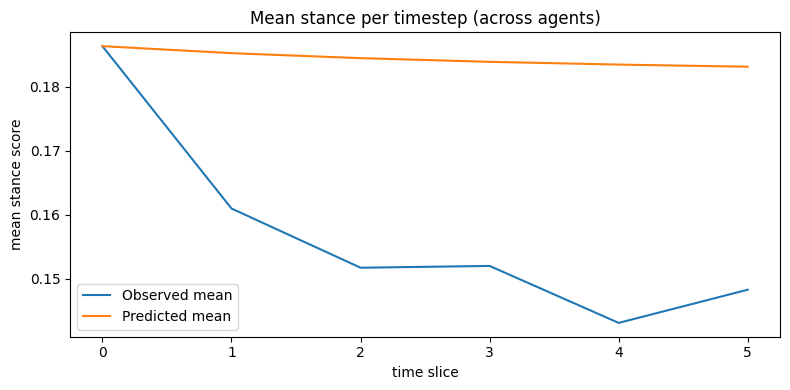

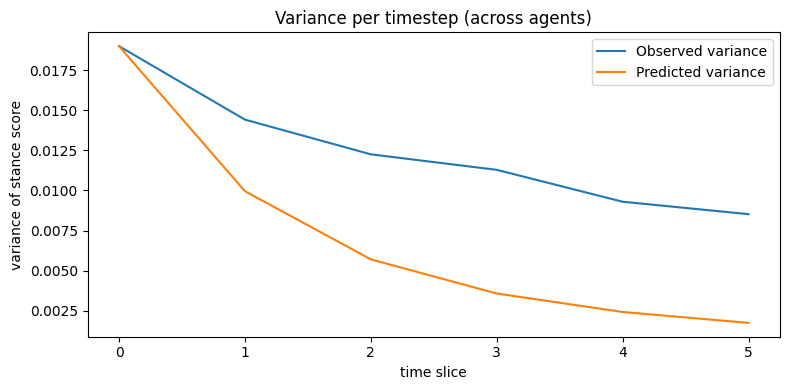

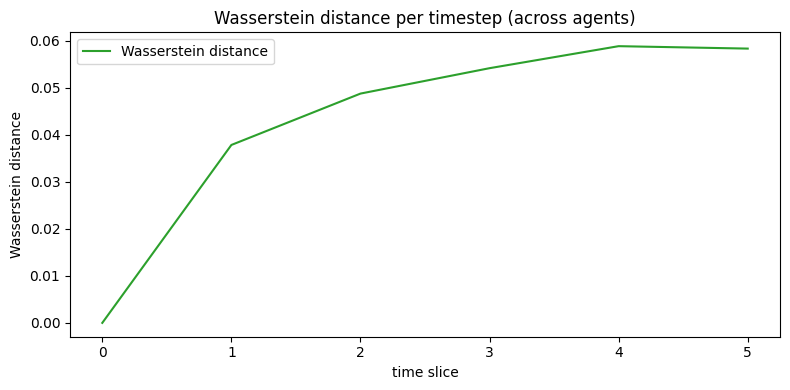

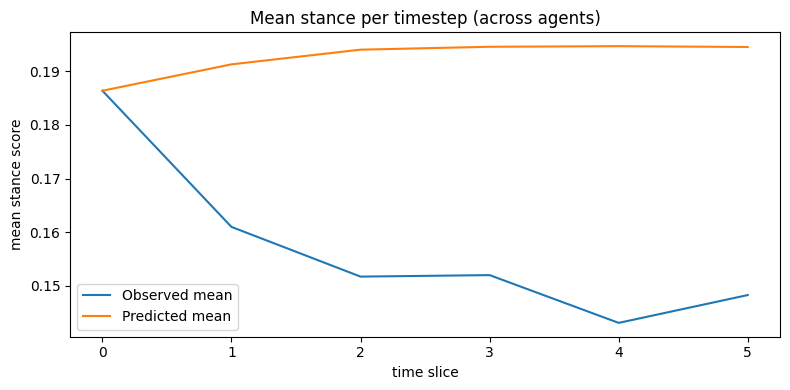

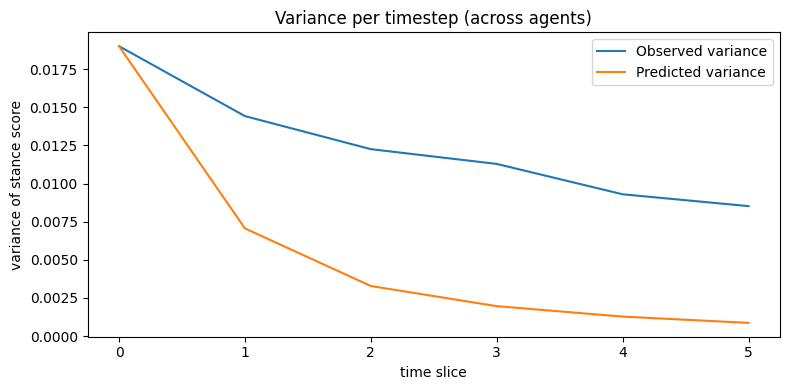

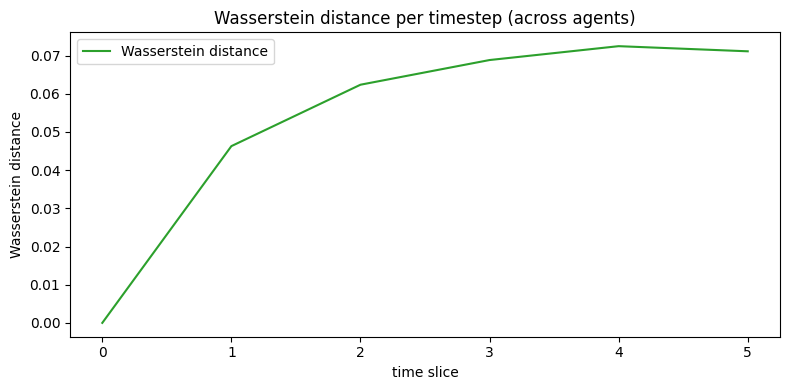

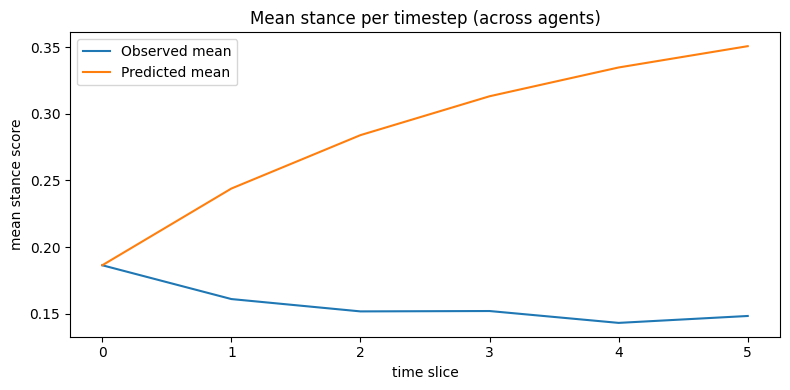

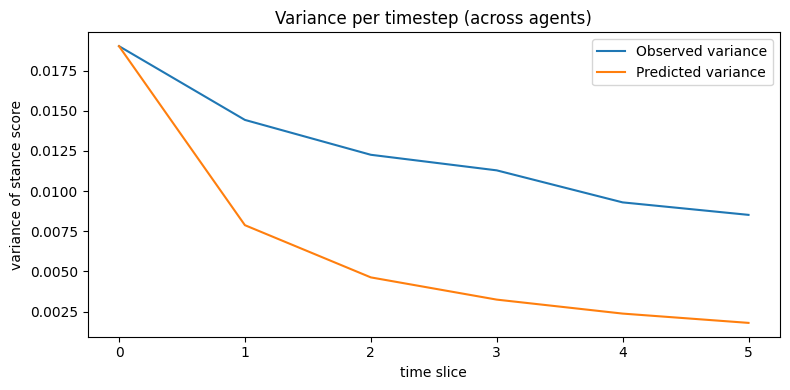

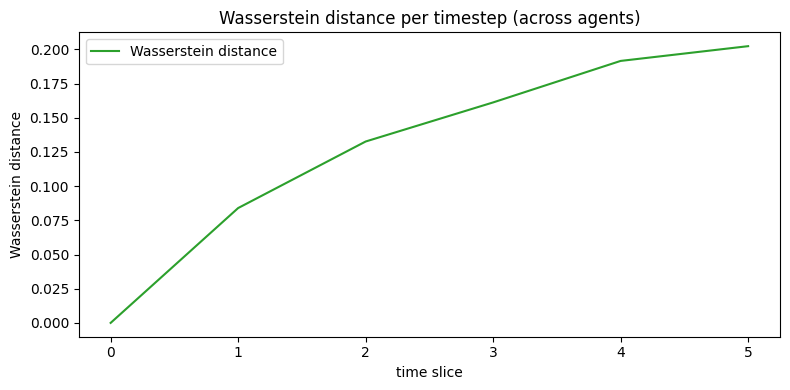

                   model  transition_mse_mean  mean_curve_abs_error  \
0                degroot             0.010510              0.031764   
1              homophily             0.011817              0.037089   
2  homophily_stubborness             0.038747              0.128378   

   var_curve_abs_error  wasserstein_curve_mean  
0             0.005441                0.042983  
1             0.006893                0.053510  
2             0.005974                0.128657  


In [8]:
TEST_DEGROOT = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_HOMO = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_HOMO_STUB = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    ),
)


VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_HOMO['mean_true_stack'].shape[1],
    TEST_HOMO_STUB['mean_true_stack'].shape[1],
)

print('Validation metric horizon (shared):', VALIDATION_CURVE_HORIZON)

plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

plot_mean_per_timestep(
    TEST_HOMO['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

plot_mean_per_timestep(
    TEST_HOMO_STUB["mean_true_stack"].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB["mean_pred_stack"].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO_STUB["var_true_stack"].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB["var_pred_stack"].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO_STUB["wasserstein_stack"].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

test_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'transition_mse_mean': TEST_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TEST_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'transition_mse_mean': TEST_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubborness',
        'transition_mse_mean': TEST_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_STUB['wasserstein_curve_mean'],
    },  
])
print(test_summary)

Validation sample run: run_20260424-032603
Plot horizon (slices): 9


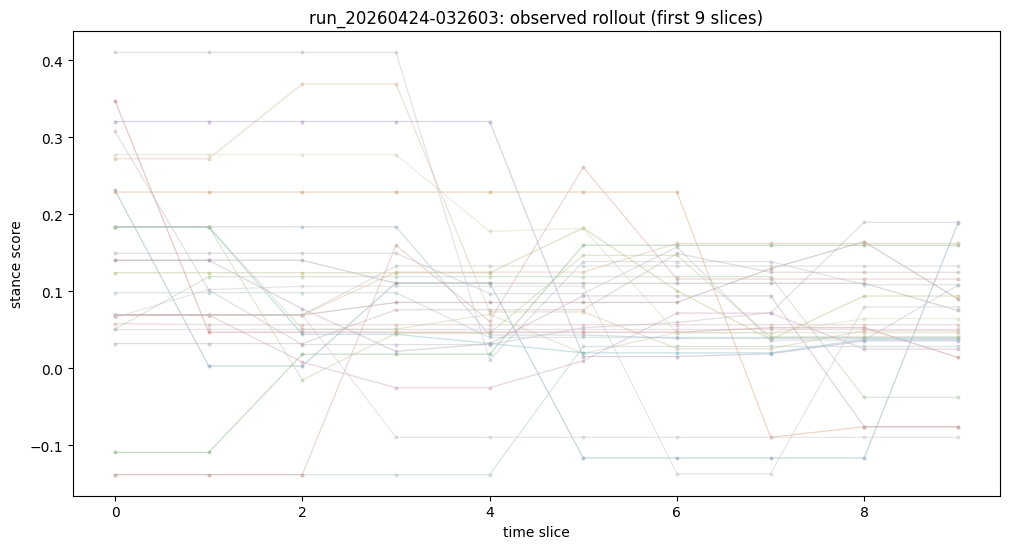

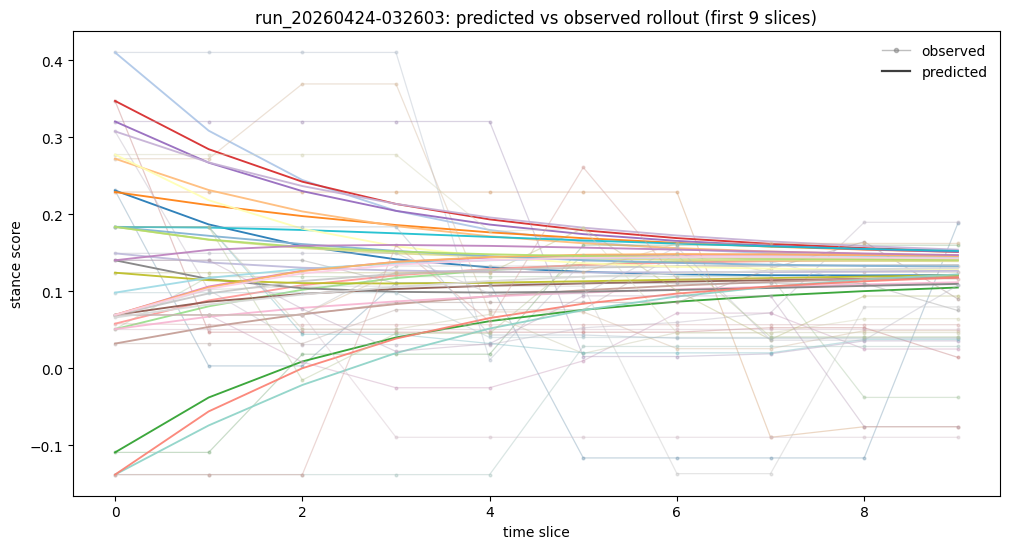

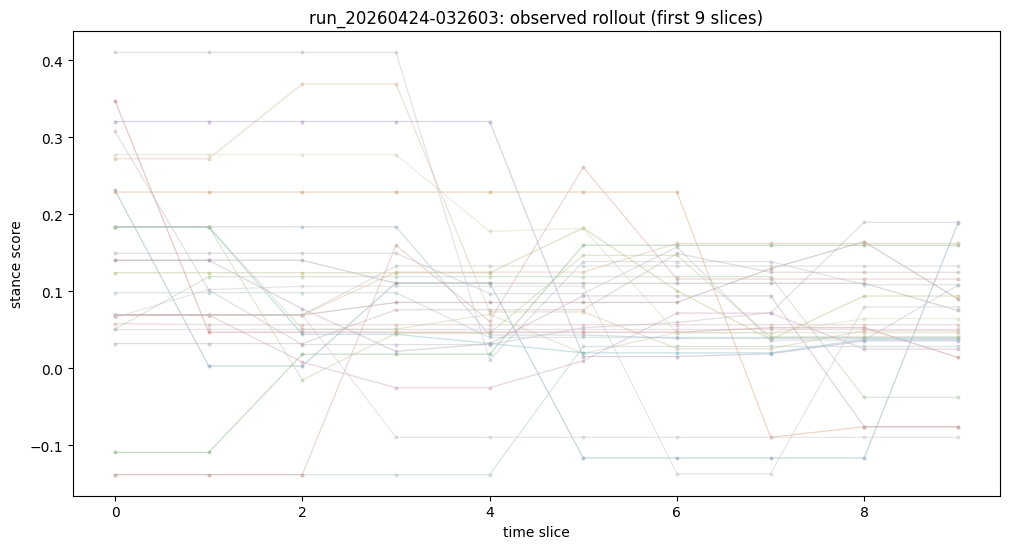

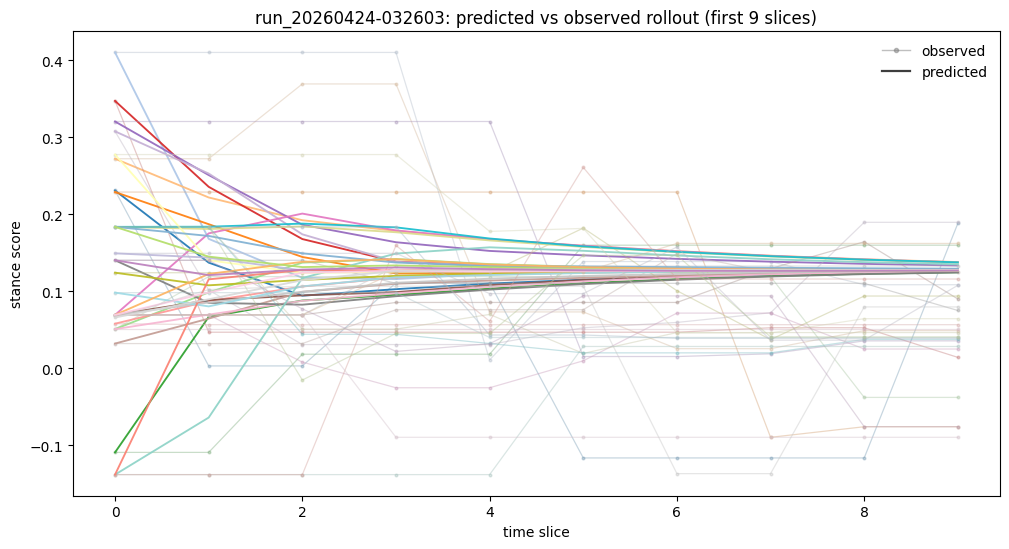

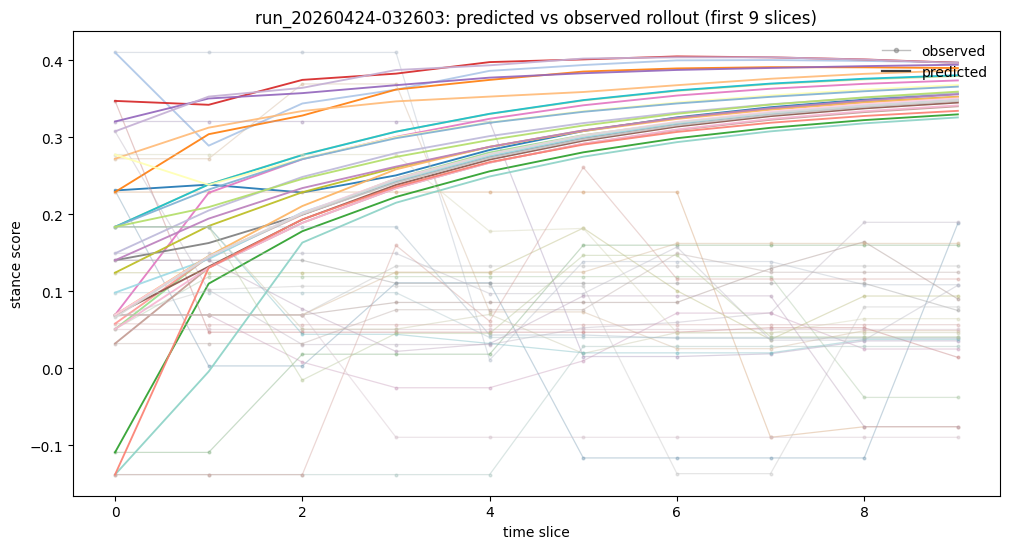

In [9]:
PREDICTED_TEST_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_DEGROOT = {
    rn: degroot_rollout_prediction(GLOBAL_W, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    )
    for rn in TEST_RUN_TRAJ.keys()
}

run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_RUN_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_RUN_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_DEGROOT[run_id], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_DEGROOT[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_HOMO[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_HOMO_STUB[run_id], GLOBAL_AGENT_IDS, plot_horizon)
